# XGBoost — r/Random_Acts_Of_Pizza request fulfillment

Binary classification, AUC-optimized. Hyperparameters from `CLAUDE.md` model notes.
Goal: beat the Logistic Regression baseline of **AUC 0.6452**.

Pipeline: shared train/test split → 5-fold stratified CV with early stopping → refit on full train → evaluate once on held-out test → save OOF + test probs to `predictions/`.

In [1]:
# Setup: on Colab, clone the repo so utils.py is importable and install needed packages.
# No-op when running locally with the conda env.
import os, sys, subprocess

REPO_URL = "https://github.com/JaeHub/the-free-pizza-project"
REPO_BRANCH = "GB"
REPO_DIR = "/content/the-free-pizza-project"

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--branch", REPO_BRANCH, REPO_URL, REPO_DIR], check=True)
    else:
        subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only"], check=True)
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)
    os.chdir(REPO_DIR)
    subprocess.run(["pip", "install", "-q", "kagglehub", "xgboost", "lightgbm"], check=True)

print("in_colab:", IN_COLAB, "| cwd:", os.getcwd())

in_colab: True | cwd: /content/the-free-pizza-project


In [2]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import roc_auc_score

from utils import (
    TARGET_COLUMN,
    RANDOM_STATE,
    load_data,
    engineer_features,
    get_train_test_split,
    get_cv_folds,
    save_predictions,
    evaluate_cv,
    evaluate_test,
    plot_feature_importance,
    log_run,
    describe_target,
    plot_cv_fold_aucs,
    plot_cv_learning_curves,
    inspect_predictions,
    print_summary,
)

MODEL_NAME = "xgboost"
print("xgboost version:", xgb.__version__)

xgboost version: 3.2.0


## Load & engineer features

In [3]:
df = load_data()
X = engineer_features(df)
y = df[TARGET_COLUMN].astype(int).values

print(f"Shape: {df.shape}\n")
describe_target(y, df)

text_len = (df["request_title"].fillna("") + " " + df["request_text_edit_aware"].fillna("")).str.split().str.len()
print(f"\nAvg request length : {text_len.mean():.0f} words")
print(f"Engineered features: {X.shape[1]}  →  {list(X.columns)}")
X.head()

Using Colab cache for faster access to the 'random-acts-of-pizza' dataset.
Shape: (4040, 32)

requester_received_pizza
False    3046
True      994
Name: count, dtype: int64

Class imbalance ratio: {False: 0.754, True: 0.246}

Avg request length : 89 words
Engineered features: 15  →  ['requester_account_age_in_days_at_request', 'requester_days_since_first_post_on_raop_at_request', 'requester_number_of_comments_at_request', 'requester_number_of_posts_at_request', 'requester_number_of_subreddits_at_request', 'requester_upvotes_minus_downvotes_at_request', 'request_hour', 'request_dow', 'title_word_count', 'title_char_count', 'body_word_count', 'body_char_count', 'has_url', 'has_question_mark', 'has_exclamation']


,requester_account_age_in_days_at_request,requester_days_since_first_post_on_raop_at_request,requester_number_of_comments_at_request,requester_number_of_posts_at_request,requester_number_of_subreddits_at_request,requester_upvotes_minus_downvotes_at_request,request_hour,request_dow,title_word_count,title_char_count,body_word_count,body_char_count,has_url,has_question_mark,has_exclamation
0,0.000000,0.000000,0,0,0,0,22,2,6,39,67,316,0,0,0
1,501.111100,0.000000,0,15,12,34,5,6,10,57,16,74,0,0,0
2,0.000000,0.000000,0,0,0,0,17,2,10,66,59,277,0,1,0
3,6.518438,0.000000,36,1,4,54,19,4,11,69,30,172,0,0,0
4,162.063252,101.606505,140,14,11,1121,19,4,14,81,103,490,0,0,1


## Train/test split (shared across all models)

In [4]:
train_idx, test_idx = get_train_test_split(y)
X_train, X_test = X.iloc[train_idx].reset_index(drop=True), X.iloc[test_idx].reset_index(drop=True)
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train: {len(y_train)} | Test: {len(y_test)}  (5-fold CV on train; no separate val split)")
print(f"  train pos rate: {y_train.mean():.3f}  |  test pos rate: {y_test.mean():.3f}")

Train: 3232 | Test: 808  (5-fold CV on train; no separate val split)
  train pos rate: 0.246  |  test pos rate: 0.246


## 5-fold stratified CV with early stopping

`scale_pos_weight` is computed on the training fold only (no leakage).

In [5]:
BASE_PARAMS = dict(
    objective="binary:logistic",
    eval_metric="auc",
    max_depth=4,
    learning_rate=0.05,
    n_estimators=1000,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    tree_method="hist",
    random_state=RANDOM_STATE,
    early_stopping_rounds=50,
)

folds = get_cv_folds(y_train)
oof_probs = np.zeros(len(y_train), dtype=float)
best_iters = []
evals_results = []

for fold_i, (tr_idx, val_idx) in enumerate(folds):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    pos = int(y_tr.sum())
    neg = len(y_tr) - pos
    spw = neg / pos

    model = xgb.XGBClassifier(scale_pos_weight=spw, **BASE_PARAMS)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    oof_probs[val_idx] = model.predict_proba(X_val)[:, 1]
    best_iters.append(model.best_iteration)
    evals_results.append(model.evals_result_)
    fold_auc = roc_auc_score(y_val, oof_probs[val_idx])
    print(f"fold {fold_i}: best_iter={model.best_iteration:4d}  val AUC={fold_auc:.4f}")

print("median best_iteration:", int(np.median(best_iters)))

fold 0: best_iter=   4  val AUC=0.6212
fold 1: best_iter=  22  val AUC=0.6461
fold 2: best_iter=   3  val AUC=0.6659
fold 3: best_iter=  48  val AUC=0.6845
fold 4: best_iter=   6  val AUC=0.6290
median best_iteration: 6


In [6]:
cv_results = evaluate_cv(y_train, oof_probs, MODEL_NAME)

[xgboost] CV AUC: 0.6493 ± 0.0233  (per-fold: [np.float64(0.6212), np.float64(0.6461), np.float64(0.6659), np.float64(0.6845), np.float64(0.629)], overall OOF: 0.6421)


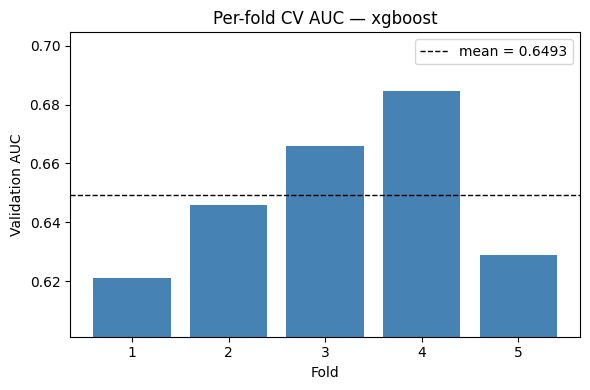

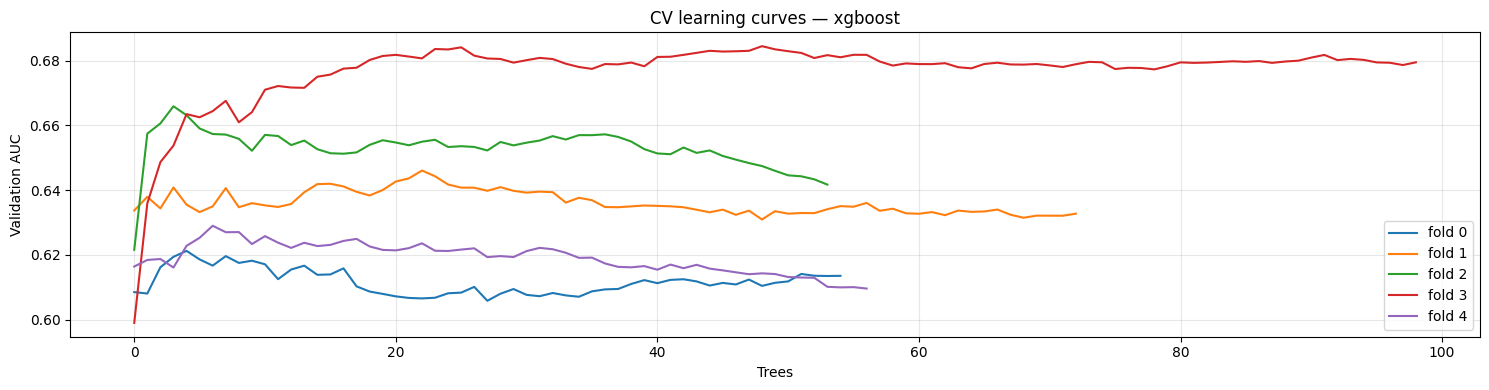

In [7]:
plot_cv_fold_aucs(cv_results["fold_aucs"], cv_results["mean"], MODEL_NAME)
plot_cv_learning_curves(evals_results, MODEL_NAME)

## Refit on full train, evaluate once on held-out test

Scale `n_estimators` up modestly (×n/(n-1) of the median best_iteration from CV) to account for using all of the training data instead of 4/5.

Test ROC-AUC: 0.5817

               precision    recall  f1-score   support

Not fulfilled       0.79      0.59      0.67       609
    Fulfilled       0.29      0.52      0.37       199

     accuracy                           0.57       808
    macro avg       0.54      0.55      0.52       808
 weighted avg       0.67      0.57      0.60       808



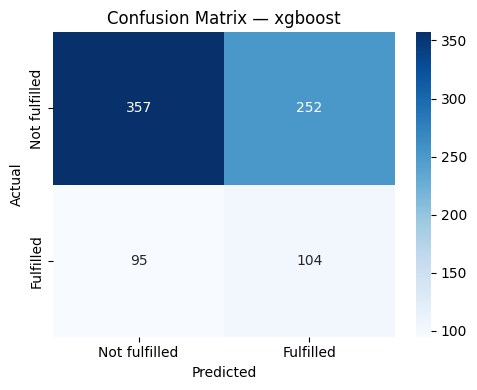

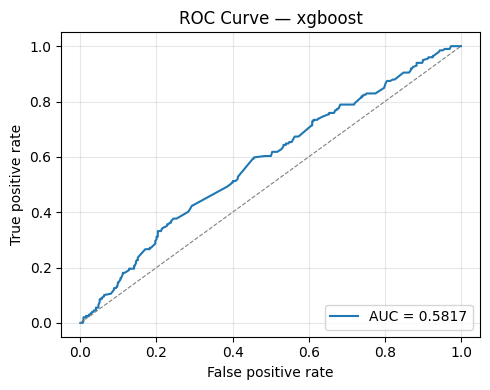

In [8]:
n_folds = len(folds)
final_n_estimators = int(np.median(best_iters) * n_folds / (n_folds - 1))

pos_full = int(y_train.sum())
neg_full = len(y_train) - pos_full
spw_full = neg_full / pos_full

FINAL_PARAMS = {**BASE_PARAMS, "n_estimators": final_n_estimators, "scale_pos_weight": spw_full}
FINAL_PARAMS.pop("early_stopping_rounds")

final_model = xgb.XGBClassifier(**FINAL_PARAMS)
final_model.fit(X_train, y_train, verbose=False)

train_probs = final_model.predict_proba(X_train)[:, 1]
test_probs = final_model.predict_proba(X_test)[:, 1]
refit_train_auc = roc_auc_score(y_train, train_probs)

test_metrics = evaluate_test(y_test, test_probs, MODEL_NAME)

## Save artifacts and inspect feature importance

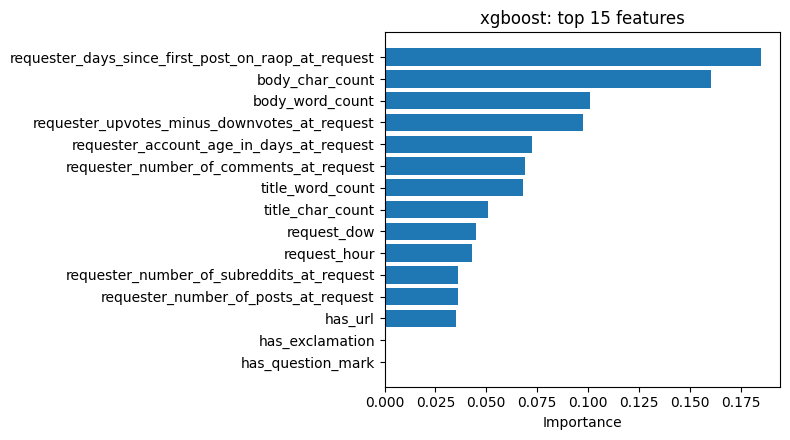

In [9]:
save_predictions(MODEL_NAME, oof_probs, test_probs)
plot_feature_importance(final_model.feature_importances_, X_train.columns, MODEL_NAME)
log_run(MODEL_NAME, FINAL_PARAMS, cv_results["mean"], cv_results["std"], test_metrics["test_auc"])

## Inspect predictions

Highest-confidence correct calls vs. confident wrong calls — same diagnostic table as `cnn_model.ipynb`.

In [10]:
y_pred = (test_probs >= 0.5).astype(int)
test_titles = df.iloc[test_idx]["request_title"].reset_index(drop=True)
inspect_predictions(test_titles, y_test, y_pred, test_probs, MODEL_NAME, n=3)

=== xgboost: Correct high-confidence predictions ===


,text,actual,confidence
647,"[Request] Blacksburg,VA",0,0.606144
183,[Request] Craving for Pizza,0,0.605744
186,[Request] Not paid in Texas,0,0.605744



=== xgboost: Confident wrong predictions ===


,text,actual,predicted,confidence
678,"[Request] Indiana, USA Would love some pizza f...",0,1,0.593047
702,[REQUEST] I'll Trade You A Laugh For A Pizza,0,1,0.590996
793,"[Request] (UK) Home alone, no bread, would app...",1,0,0.588641


## Key Findings Summary

In [11]:
top_features = (
    pd.Series(final_model.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
    .head(3)
    .index.tolist()
)
overfit_gap = refit_train_auc - cv_results["mean"]
overfit_note = "modest overfit" if overfit_gap < 0.05 else "noticeable overfit (consider raising regularization)"
beats_lr = test_metrics["test_auc"] > 0.6452
lr_note = (
    f"beats LR baseline (Δ = {test_metrics['test_auc']-0.6452:+.4f})"
    if beats_lr else f"below LR baseline (Δ = {test_metrics['test_auc']-0.6452:+.4f})"
)

print_summary(
    MODEL_NAME,
    dataset={
        "total_samples": len(df),
        "fulfillment_rate_pct": float(df[TARGET_COLUMN].mean() * 100),
        "n_features": X.shape[1],
    },
    model={
        "name": "XGBoost",
        "params_summary": (
            f"max_depth={FINAL_PARAMS['max_depth']}, lr={FINAL_PARAMS['learning_rate']}, "
            f"n_estimators={FINAL_PARAMS['n_estimators']}, subsample={FINAL_PARAMS['subsample']}, "
            f"colsample={FINAL_PARAMS['colsample_bytree']}"
        ),
        "class_handling": f"scale_pos_weight={spw_full:.2f}",
    },
    training={
        "cv_auc_mean": cv_results["mean"],
        "cv_auc_std": cv_results["std"],
        "fold_aucs": cv_results["fold_aucs"],
        "median_best_iter": int(np.median(best_iters)),
        "refit_train_auc": refit_train_auc,
    },
    test={
        "roc_auc": test_metrics["test_auc"],
        "f1_fulfilled": test_metrics["f1_fulfilled"],
        "accuracy_pct": test_metrics["accuracy"] * 100,
    },
    takeaways=[
        f"Test AUC {lr_note}; CNN baseline 0.5846.",
        f"Top 3 features by importance: {', '.join(top_features)}.",
        f"Refit-train vs CV AUC gap = {overfit_gap:+.4f} → {overfit_note}.",
        f"Early stopping picked median {int(np.median(best_iters))} trees of {BASE_PARAMS['n_estimators']} budget — well below the cap.",
    ],
)

       XGBOOST — KEY FINDINGS SUMMARY

📦 Dataset
   Total samples      : 4,040
   Fulfillment rate   : 24.6%  (class imbalance 75/25)
   Features used      : 15  (leakage-safe)

🧠 Model — XGBoost
   Hyperparameters    : max_depth=4, lr=0.05, n_estimators=7, subsample=0.8, colsample=0.8
   Class handling     : scale_pos_weight=3.07

📈 Cross-validation
   CV AUC             : 0.6493 ± 0.0233
   Per-fold AUCs      : [np.float64(0.6212), np.float64(0.6461), np.float64(0.6659), np.float64(0.6845), np.float64(0.629)]
   Median best_iter   : 6
   Refit train AUC    : 0.7079  (gap vs CV = +0.0586)

🎯 Test Performance
   ROC-AUC            : 0.5817  (LR baseline = 0.6452, Δ = -0.0635)
   F1 (fulfilled)     : 0.3748
   Accuracy           : 57.1%

💡 Key Takeaways
   • Test AUC below LR baseline (Δ = -0.0635); CNN baseline 0.5846.
   • Top 3 features by importance: requester_days_since_first_post_on_raop_at_request, body_char_count, body_word_count.
   • Refit-train vs CV AUC gap = +0.0586 → notic